# 04 — Stage 1 Trend Label Generation (V5 Phase 3)

**BBL514E Pattern Recognition — Term Project**

Stage 1 hedef etiketi: günlük `uptrend / downtrend / range` (3-class). Bu notebook iki ortogonal yaklaşımı BTC ve ETH üzerinde dener:

1. **Forward-return + adaptive threshold** — t+h log return rolling-std × k karşılaştırması
2. **ZigZag piecewise segmentation** — pivot-to-pivot direction + amplitude/duration filtreleri

CLAUDE.md kuralı: SMA crossover **kullanmıyoruz** (önceki proje iter'larında tautoloji yarattı — feature space'le yarı-çizgisel ilişki, MLP ezbere %82 öğrendi).

**Hedef:** 3-class dengeli + causal label. Kullanıcı review sonrası tercih edilen yöntem `src/labels/v5_trend_labels.py` üzerinden Stage 1 training'e geçer.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from src.labels.v5_trend_labels import (
    forward_return_trend_label, zigzag_trend_label,
    find_zigzag_pivots, label_distribution, TREND_LABELS,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

proc = PROJECT_ROOT / "data" / "processed"
btc = pd.read_csv(proc / "btc_aligned_v5.csv", index_col=0, parse_dates=True)
eth = pd.read_csv(proc / "eth_aligned_v5.csv", index_col=0, parse_dates=True)

LABEL_COLORS = {"uptrend": "#7ec27e", "downtrend": "#e07e7e", "range": "#f0c870"}
print(f"BTC: {len(btc)} rows  {btc.index.min().date()} -> {btc.index.max().date()}")
print(f"ETH: {len(eth)} rows  {eth.index.min().date()} -> {eth.index.max().date()}")

BTC: 4094 rows  2014-09-17 -> 2025-12-30
ETH: 2955 rows  2017-11-09 -> 2025-12-30


## 1. Forward-return + adaptive threshold — parametre taraması

`label_t = uptrend  if log_ret_h(t) > +k × rolling_std`
`label_t = downtrend if log_ret_h(t) < -k × rolling_std`
`label_t = range    otherwise`

Hedef: 3 sınıfın dengeli dağılımı (her biri yaklaşık %25-50 arası).

In [2]:
configs_fr = [
    {"horizon": 5,  "rolling_window": 252, "threshold_k": 0.5},
    {"horizon": 5,  "rolling_window": 252, "threshold_k": 0.75},
    {"horizon": 10, "rolling_window": 252, "threshold_k": 0.5},
    {"horizon": 10, "rolling_window": 252, "threshold_k": 1.0},
    {"horizon": 20, "rolling_window": 252, "threshold_k": 0.75},
    {"horizon": 20, "rolling_window": 252, "threshold_k": 1.0},
]
rows = []
for cfg in configs_fr:
    btc_lab = forward_return_trend_label(btc["Close"], **cfg)
    eth_lab = forward_return_trend_label(eth["Close"], **cfg)
    btc_d = label_distribution(btc_lab["label"])
    eth_d = label_distribution(eth_lab["label"])
    rows.append({
        "config": f"h={cfg['horizon']:2d}, k={cfg['threshold_k']:.2f}",
        "BTC up":   f"{btc_d['uptrend']:.2%}",   "BTC down":   f"{btc_d['downtrend']:.2%}",   "BTC range":   f"{btc_d['range']:.2%}",
        "ETH up":   f"{eth_d['uptrend']:.2%}",   "ETH down":   f"{eth_d['downtrend']:.2%}",   "ETH range":   f"{eth_d['range']:.2%}",
    })
pd.DataFrame(rows)

,config,BTC up,BTC down,BTC range,ETH up,ETH down,ETH range
0,"h= 5, k=0.50",29.48%,22.33%,48.19%,27.81%,24.07%,48.11%
1,"h= 5, k=0.75",21.76%,15.96%,62.28%,20.34%,17.78%,61.88%
2,"h=10, k=0.50",31.13%,22.91%,45.96%,29.21%,26.09%,44.70%
3,"h=10, k=1.00",17.49%,10.61%,71.90%,15.35%,12.72%,71.93%
4,"h=20, k=0.75",27.02%,16.46%,56.51%,24.10%,19.82%,56.08%
5,"h=20, k=1.00",20.90%,10.96%,68.14%,18.32%,13.14%,68.53%


## 2. ZigZag piecewise segmentation — parametre taraması

Pivot detection threshold (deviation_pct), minimum segment days, range amplitude eşiği değişkenleri.

In [3]:
configs_zz = [
    {"deviation_pct": 0.05, "min_segment_days": 10, "range_amplitude": 0.025},
    {"deviation_pct": 0.10, "min_segment_days": 10, "range_amplitude": 0.05},
    {"deviation_pct": 0.10, "min_segment_days": 20, "range_amplitude": 0.05},
    {"deviation_pct": 0.15, "min_segment_days": 15, "range_amplitude": 0.075},
    {"deviation_pct": 0.20, "min_segment_days": 20, "range_amplitude": 0.10},
]
rows = []
for cfg in configs_zz:
    btc_lab = zigzag_trend_label(btc["Close"], **cfg)
    eth_lab = zigzag_trend_label(eth["Close"], **cfg)
    btc_d = label_distribution(btc_lab["label"])
    eth_d = label_distribution(eth_lab["label"])
    btc_segs = btc_lab["segment_id"].nunique()
    eth_segs = eth_lab["segment_id"].nunique()
    rows.append({
        "config": f"dev={cfg['deviation_pct']:.0%}, min={cfg['min_segment_days']}d, amp={cfg['range_amplitude']:.1%}",
        "BTC up":  f"{btc_d['uptrend']:.2%}",  "BTC down":  f"{btc_d['downtrend']:.2%}",  "BTC range":  f"{btc_d['range']:.2%}",
        "BTC segs": btc_segs,
        "ETH up":  f"{eth_d['uptrend']:.2%}",  "ETH down":  f"{eth_d['downtrend']:.2%}",  "ETH range":  f"{eth_d['range']:.2%}",
        "ETH segs": eth_segs,
    })
pd.DataFrame(rows)

,config,BTC up,BTC down,BTC range,BTC segs,ETH up,ETH down,ETH range,ETH segs
0,"dev=5%, min=10d, amp=2.5%",44.09%,26.53%,29.38%,415,31.95%,22.13%,45.92%,410
1,"dev=10%, min=10d, amp=5.0%",56.20%,33.51%,10.28%,188,50.90%,34.59%,14.52%,192
2,"dev=10%, min=20d, amp=5.0%",51.00%,24.45%,24.55%,188,37.12%,22.20%,40.68%,192
3,"dev=15%, min=15d, amp=7.5%",57.35%,34.88%,7.77%,115,50.19%,34.65%,15.16%,107
4,"dev=20%, min=20d, amp=10.0%",61.70%,34.34%,3.96%,71,50.42%,40.85%,8.73%,61


## 3. Aday yapılandırmaların timeline karşılaştırması

İki dengeli aday seç ve BTC üzerinde shading + price overlay göster.

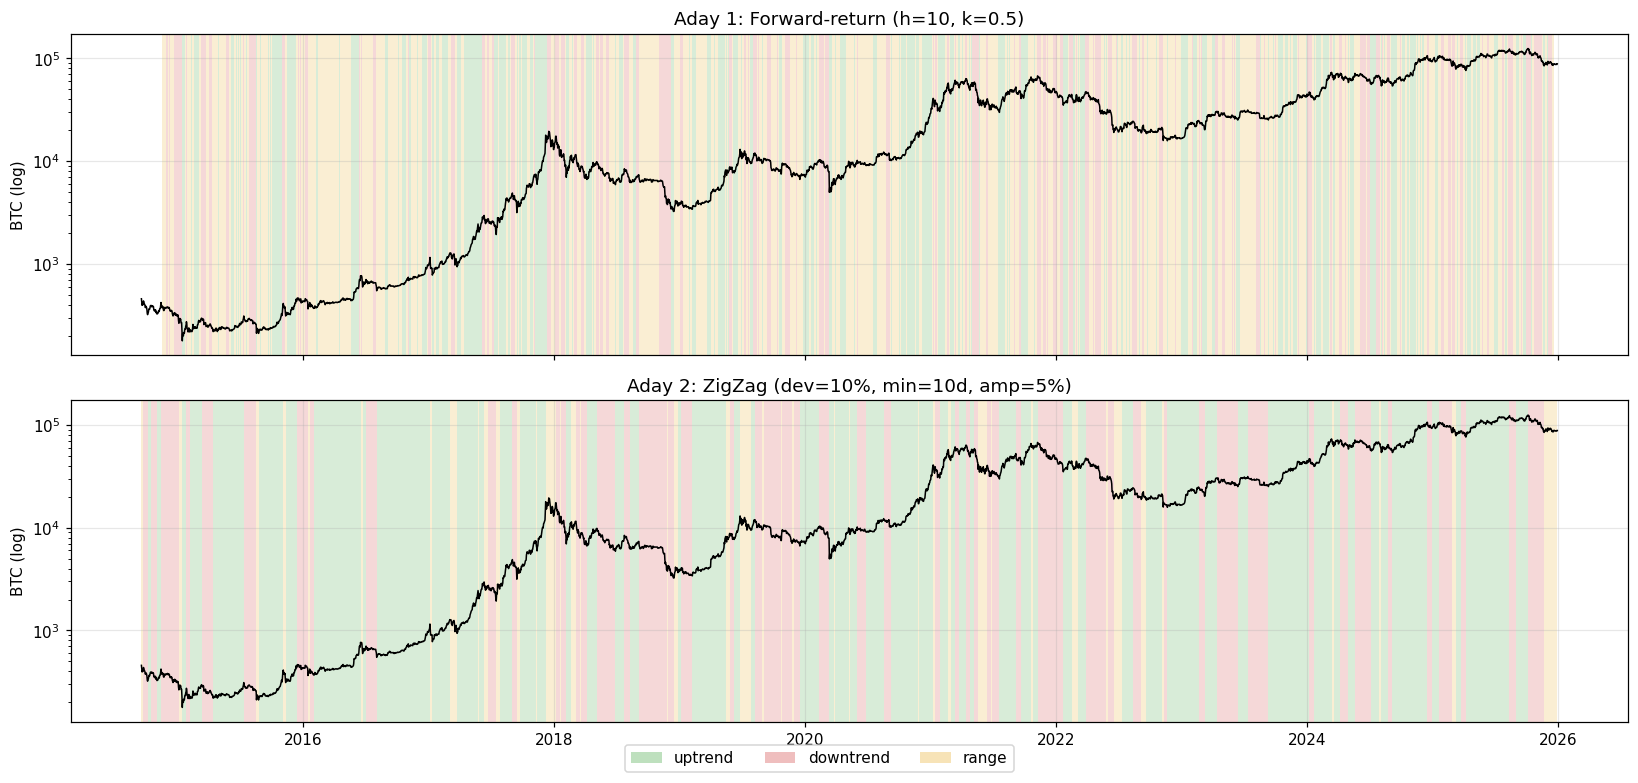

In [4]:
def shade(ax, label_series):
    label_series = label_series.dropna()
    if label_series.empty: return
    cur, start = label_series.iloc[0], label_series.index[0]
    for i in range(1, len(label_series)):
        v = label_series.iloc[i]
        if v != cur:
            ax.axvspan(start, label_series.index[i], color=LABEL_COLORS.get(cur, "white"), alpha=0.30, lw=0)
            cur, start = v, label_series.index[i]
    ax.axvspan(start, label_series.index[-1], color=LABEL_COLORS.get(cur, "white"), alpha=0.30, lw=0)

# Aday 1: forward-return h=10, k=0.5
fr_label = forward_return_trend_label(btc["Close"], horizon=10, rolling_window=252, threshold_k=0.5)
# Aday 2: ZigZag dev=10%, min=10d, amp=5%
zz_label = zigzag_trend_label(btc["Close"], deviation_pct=0.10, min_segment_days=10, range_amplitude=0.05)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
shade(axes[0], fr_label["label"])
axes[0].semilogy(btc.index, btc["Close"], color="black", lw=1.0)
axes[0].set_ylabel("BTC (log)"); axes[0].set_title("Aday 1: Forward-return (h=10, k=0.5)")

shade(axes[1], zz_label["label"])
axes[1].semilogy(btc.index, btc["Close"], color="black", lw=1.0)
axes[1].set_ylabel("BTC (log)"); axes[1].set_title("Aday 2: ZigZag (dev=10%, min=10d, amp=5%)")

handles = [Patch(facecolor=c, alpha=0.5, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plt.show()

## 4. ETH timeline (aynı iki aday)

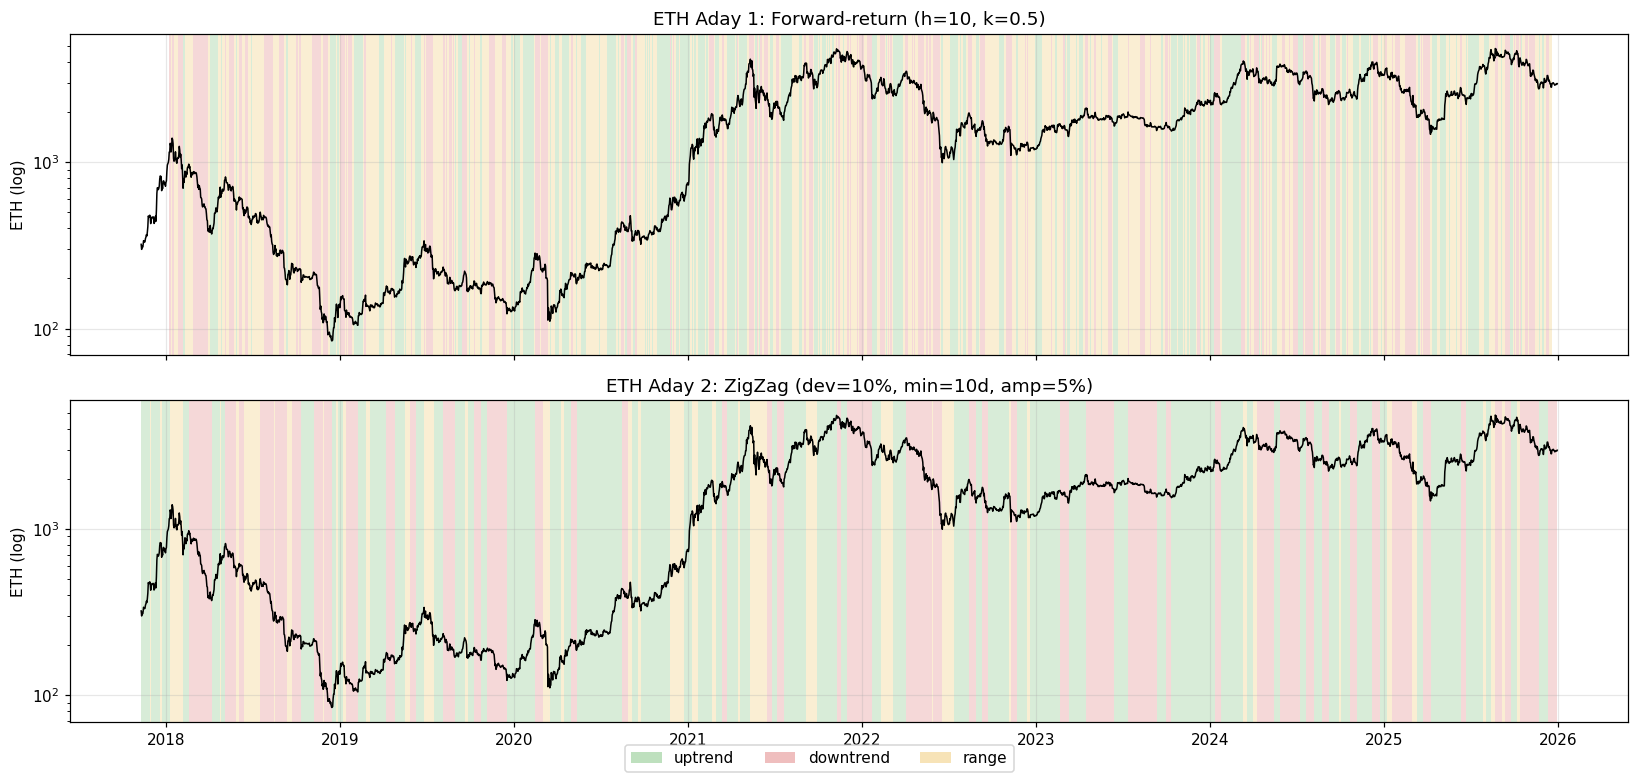

In [5]:
fr_label_eth = forward_return_trend_label(eth["Close"], horizon=10, rolling_window=252, threshold_k=0.5)
zz_label_eth = zigzag_trend_label(eth["Close"], deviation_pct=0.10, min_segment_days=10, range_amplitude=0.05)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
shade(axes[0], fr_label_eth["label"])
axes[0].semilogy(eth.index, eth["Close"], color="black", lw=1.0)
axes[0].set_ylabel("ETH (log)"); axes[0].set_title("ETH Aday 1: Forward-return (h=10, k=0.5)")

shade(axes[1], zz_label_eth["label"])
axes[1].semilogy(eth.index, eth["Close"], color="black", lw=1.0)
axes[1].set_ylabel("ETH (log)"); axes[1].set_title("ETH Aday 2: ZigZag (dev=10%, min=10d, amp=5%)")

handles = [Patch(facecolor=c, alpha=0.5, label=l) for l, c in LABEL_COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plt.show()

## 5. Aday özet karşılaştırması

| Kriter | Forward-return (h=10, k=0.5) | ZigZag (dev=10%, min=10d, amp=5%) |
|---|---|---|
| Tasarım | Threshold-based, adaptive | Pivot-based, segment'a göre |
| Causal | t+h kullanır (training-only valid) | Pivots retrospective ama offline |
| Tautoloji riski | Düşük (return-based, feature ortogonal) | Düşük (price-only, OHLCV feature ortogonal) |
| Yumuşaklık | Günlük dalgalanma (high noise) | Trend-stable (segment içinde sabit) |
| Dengeli mi | k seçimine bağlı | dev/amp seçimine bağlı |

In [6]:
btc_fr_dist = label_distribution(fr_label["label"])
btc_zz_dist = label_distribution(zz_label["label"])
eth_fr_dist = label_distribution(fr_label_eth["label"])
eth_zz_dist = label_distribution(zz_label_eth["label"])

summary = pd.DataFrame({
    "BTC FR (h=10,k=0.5)": btc_fr_dist,
    "BTC ZZ (dev=10%)":    btc_zz_dist,
    "ETH FR (h=10,k=0.5)": eth_fr_dist,
    "ETH ZZ (dev=10%)":    eth_zz_dist,
}).round(3)
summary

,"BTC FR (h=10,k=0.5)",BTC ZZ (dev=10%),"ETH FR (h=10,k=0.5)",ETH ZZ (dev=10%)
label,,,,
uptrend,0.311,0.562,0.292,0.509
downtrend,0.229,0.335,0.261,0.346
range,0.460,0.103,0.447,0.145


## 6. Kullanıcı review notları

**Forward-return tradeoff:**
- Pro: Adaptive threshold, volatilite ile ölçeklenir → farklı dönemler için stable
- Con: Day-to-day label flip-flop'u olabilir (range/uptrend kenarda)

**ZigZag tradeoff:**
- Pro: Trend-stable etiket (segment boyunca aynı), gözle anlamlı
- Con: Pivots retrospective tanımlı — son segment "open-ended" (henüz pivot olmadı)

Sonraki adım: Kullanıcı tercihi → Stage 1 features + 4-classifier walk-forward training.